In [8]:
import jax
import numpy as np
import time

import jVMC_exp
from jVMC_exp.util import measure
import jVMC_exp.operator.discrete as op

import matplotlib.pyplot as plt

In [ ]:
L = 6
g = -0.7
h = 0.1

dt = 1e-3  # Initial time step
integratorTol = 1e-4  # Adaptive integrator tolerance
t_max = 2  # Final time

batch_size = 2**L 

# Set up variational wave function
net = jVMC_exp.nets.CpxRBM(numHidden=10, bias=True)
psi = jVMC_exp.vqs.NQS(net, sampleShape=L, batchSize=batch_size, seed=123)  # Variational wave function

# Set up exact sampler
sampler = jVMC_exp.sampler.ExactSampler(psi)

print("Number of parameters: ", psi.numParameters)

In [10]:
# Set up hamiltonian
hamiltonian = 0
M_x = 0
for l in range(L):
    hamiltonian += -1 * op.SigmaZ(l) * op.SigmaZ((l + 1) % L) + g * op.SigmaX(l) + h * op.SigmaZ(l)
    M_x += op.SigmaX(l)
M_x /= L

# Set up observables
observables = {
    "X": M_x,
}

In [11]:

# Set up optimization problem
stepper = jVMC_exp.stepper.AdaptiveHeun(timeStep=dt, tol=integratorTol)
solver = jVMC_exp.solver.PinvSNR(pinv_tol=1e-8)
loss_function = jVMC_exp.objective_function.Observable(hamiltonian)
opt = jVMC_exp.optimizer.TDVP(sampler, psi, make_real=False, solver=solver)

/home/msolionas/code/Custom_jVMC/jVMC_exp/optimizer/base.py:249: UserWarning: Naming convention changed: 'diag_shift' now adds a constant term to the diagonal, while 'diag_scale' multiplies the diagonal entries. This is the opposite of the previous convention.
  warnings.warn(


In [12]:
out = opt.time_evolution(t_max, loss_function, stepper, observables=observables)

590it [02:14,  4.38it/s, t=1.9976/2, dt=4.54e-03, ETA=0.0s, Progress=99%, E=-4.1994e+00-2.7756e-17j ± 8.7116e-01 (Var = 6.0643e+00)]                      

Recorded timings:
    • sampling: 4.669592s
    • compute objective function and gradient: 36.047708s
    • solve: 75.432264s


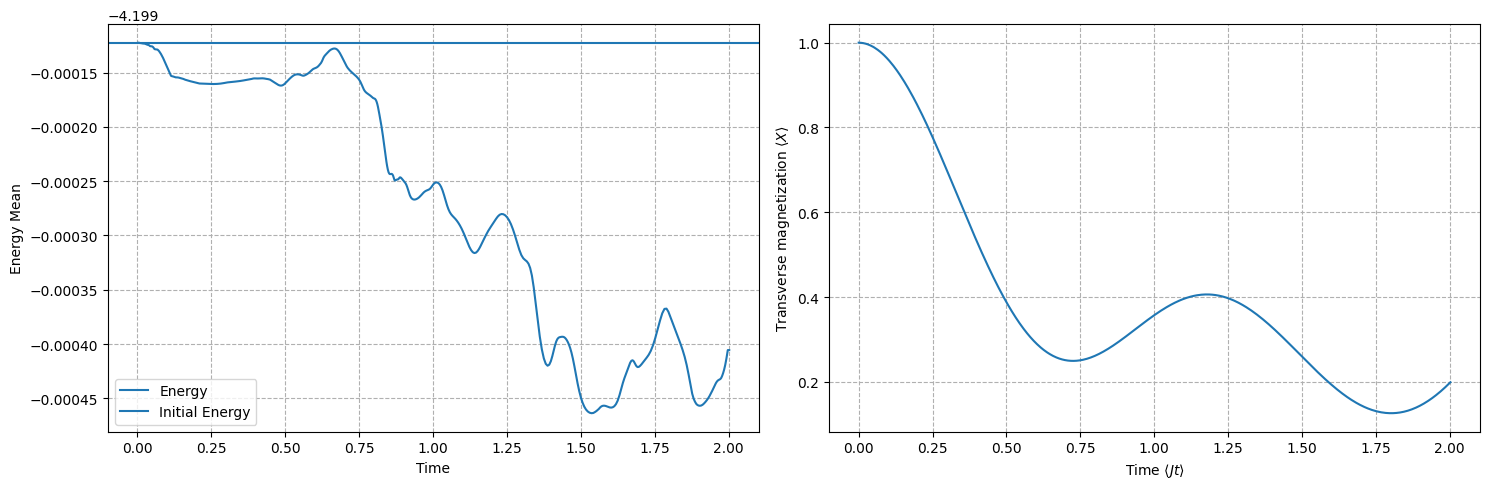

In [22]:
time = out["times"]
energy_mean = np.array(out["energy"]["mean"]).real
energy_err = np.array(out["energy"]["MC_error"])
magnetization = np.array(out["X"]["mean"])

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(time, energy_mean, label="Energy")
plt.axhline(energy_mean[0].item(), label="Initial Energy")
plt.ylabel("Energy Mean")
plt.xlabel("Time")
plt.grid(ls="--")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time, magnetization)
plt.ylabel(r"Transverse magnetization $\langle X\rangle$")
plt.xlabel(r"Time $\langle Jt\rangle$")
plt.grid(ls="--")

plt.tight_layout()